In [1]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import time
import pennylane as qml
import dimod
import pandas as pd
from itertools import product
from scipy.optimize import minimize

import qubo_engine as qe

In [2]:
np.random.seed(42)

tickers = ["AAPL", "MSFT" , 'GS']
data = yf.download(tickers,start='2020-01-01', end='2026-01-01')
prices=data["Close"]
log_returns = np.log(prices/prices.shift(1)).dropna()

mean_returns= log_returns.mean().values *252
cov_matrix = log_returns.cov().values*252
sector_map={0:0,1:0,2:1}

n_assets=3
n_bits=2
N=n_assets*n_bits

# cov_matrix.head()
# mean_returns.head()


[*********************100%***********************]  3 of 3 completed


**Cell 3**

Integrated sector constraints into the portfolio optimization engine I built and imported it, and set the sector cap to 0.6 so it's identical to the sector constraints imposed on all other methods in this notebook. This gives the best-case classical answer to the Markowitz over continuous weights and isolates the cost of discretization and penalty softness from the actual cost of discretization.

In [3]:
import sys
sys.path.append('/Users/linanachdi/Documents/GitHub/portfolio-optimization-engine')
import portfolio_engine as pe

start= time.time()

mw_weights,mw_ret,mw_vol,mw_sharpe = pe.maximum_sharpe(mean_returns,cov_matrix,sector_map=sector_map, sector_cap=0.6)

mw_time=time.time()-start

print("Constrained Markowitz weights:")
for ticker,w in zip(tickers,mw_weights):
    print(f"{ticker}:{w:.4f}")
print(f"Returns: {mw_ret:.2%} | Vol: {mw_vol:.2%} | Sharpe: {mw_sharpe:.4f}")
print(f"Time taken: {mw_time:.4f}s")

Constrained Markowitz weights:
AAPL:0.1540
MSFT:0.4460
GS:0.4000
Returns: 22.05% | Vol: 26.34% | Sharpe: 0.6585
Time taken: 0.0045s


**Cell 4**

Built a QUBO engine using the same structure as the one used in week 1 and 2, with linear return term on the diagonal and the quadratic risk term expanded in binary, and the squared penalty terms enforce the budget and sector constraints at strength lambda. Brute force checks all 2^N combinations one by one and give sus the true minimum. SA is the heuristic classical comparison.

Results: SA was able to find the true optimal so SA energy=Brute force energy. As well, the cell reconverts/decodes the weights from binary back to portfolio weights. We notice that the weights of BF and SA are very similar to those of the Markowitz in the cell above.


In [4]:

Q= qe.build_qubo_matrix(mean_returns,cov_matrix,lambda_risk=1.0,lambda_budget=5.0,lambda_sector=2.0,sector_map=sector_map,
                        sector_cap=0.6,n_assets=n_assets,n_bits=n_bits)

start=time.time()
x_brute,energy_brute=qe.brute_force_qubo(Q)
time_brute=time.time() - start

start=time.time()
x_sa,energy_sa = qe.simulated_annealing_qubo(Q,num_reads=1000,num_sweeps=1000)
time_sa = time.time() - start

weights_brute = qe.decode_weights(x_brute,n_assets,n_bits)
weights_sa = qe.decode_weights(x_sa,n_assets,n_bits)

print(f"Brute force | energy: {energy_brute:.4f} | time: {time_brute:.4f}s")
print(f"Simulated Annealing | energy: {energy_sa:.4f} | time: {time_sa:.4f}s")
print("\nBrute force weights:")
for ticker,w_b in zip(tickers,weights_brute):
    print(f"{ticker}: {w_b:.4f}")
print("\nSA weights:")
for ticker,w_sa in zip(tickers,weights_sa):
    print(f"{ticker}:{w_sa:.4f}")

Brute force | energy: -6.4394 | time: 0.0004s
Simulated Annealing | energy: -6.4394 | time: 9.2153s

Brute force weights:
AAPL: 0.3333
MSFT: 0.3333
GS: 0.3333

SA weights:
AAPL:0.3333
MSFT:0.3333
GS:0.3333


**Cell 5**

Use the same quantum-classical hybrid from week 3, with wall-clock time same as the other methods, and with total circuit evaluations tracked per restart which esentially gives us the 'work done' so we can make a fair comaprison across methods.

Results:

In [5]:
# copy QAOA qubo to ising hamiltonian with cost and mixer layers from week 3

def qubo_to_ising_hamiltonian(Q):
    n=Q.shape[0]
    coeffs=[]
    obs=[]

    offset=0.0
    linear=np.zeros(n)
    quadratic={}

    for i in range(n):
        for j in range(n):
            if Q[i,j] == 0:
                continue
            if i==j:
                offset += Q[i,i]/2
                linear[i] += -Q[i,i]/2
            else:
                offset += Q[i,j]/4
                linear[i] += -Q[i,j]/4
                linear[j] += -Q[i,j]/4
                key=tuple(sorted((i,j)))
                quadratic[key]=quadratic.get(key,0) + Q[i,j]/4

    for i in range(n):
        if linear[i] != 0:
            coeffs.append(linear[i])
            obs.append(qml.PauliZ(i))
    for (i,j), coeff in quadratic.items():
        if coeff != 0:
            coeffs.append(coeff)
            obs.append(qml.PauliZ(i) @ qml.PauliZ(j))

    return coeffs, obs, offset

coeffs,obs,offset = qubo_to_ising_hamiltonian(Q)
cost_hamiltonian = qml.Hamiltonian(coeffs,obs)

n_qubits=N
dev=qml.device("default.qubit",wires=n_qubits)

def cost_layer(gamma,cost_hamiltonian):
    qml.templates.ApproxTimeEvolution(cost_hamiltonian,gamma,1)

def mixer_layer(beta):
    for i in range(n_qubits):
        qml.RX(2*beta,wires=i)

@qml.qnode(dev)
def qaoa_circuit(params,p):
    gammas = params[:p]
    betas = params[p:]

    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    for layer in range(p):
        cost_layer(gammas[layer],cost_hamiltonian)
        mixer_layer(betas[layer])

    return qml.expval(cost_hamiltonian)
    

In [6]:
def run_qaoa(p=1,n_restarts=5,maxiter=300):
    best_result,best_cost = None,np.inf
    history = []
    total_nfev = 0
    start_time=time.time()

    for restart in range(n_restarts):
        params0=np.random.uniform(0,np.pi,size=2*p)
        result= minimize(lambda params: qaoa_circuit(params,p), params0,method = "COBYLA", options={"maxiter":maxiter})
        history.append(result.fun)
        total_nfev += result.nfev
        if result.fun < best_cost:
            best_cost, best_result = result.fun , result

    time_taken = time.time() - start_time
    return best_result, best_cost,history,time_taken,total_nfev

result_p1, cost_p1,history_p1,time_p1,nfev_p1 = run_qaoa(p=1, n_restarts = 5)
result_p2, cost_p2, history_p2, time_p2, nfev_p2 = run_qaoa(p=2, n_restarts=15)

print(f"QAOA p=1 | energy: {cost_p1+offset:.4f} | time: {time_p1:.2f}s | evals: {nfev_p1}")
print(f"QAOA p=2 | energy: {cost_p2+offset:.4f} | time: {time_p2:.2f}s | evals: {nfev_p2}")

QAOA p=1 | energy: -2.6054 | time: 0.90s | evals: 319
QAOA p=2 | energy: -5.2482 | time: 12.46s | evals: 3032


In [7]:
print(f"{'Method':<25}{'Energy':>20}{'Time(s)':>20}{'Work':>20}")
print(f"{"Constrained Markowitz":<20} {'N/A':>20} {mw_time:>20.4f}{'Solved in 1 SLQSP run':>30}")
print(f"{'Brute Force':<25}{energy_brute:>20.4f}{time_brute:>20.4f}{str(2**N)+ ' combinations':>25}")
sa_work = 1000*1000*N  #Total work= num_reads*num_sweeps*variables
print(f"{'Simulated Annealing':<25}{energy_sa:>20.4f}{time_sa:>20.4f}{str(sa_work) + " variable flips":>30}")
print(f"{'QAOA p=1':<25}{cost_p1+offset:>20.4f}{time_p1:>20.4f}{str(nfev_p1) + " evals":>25}")
print(f"{'QAOA p=2':<25}{cost_p2+offset:>20.4f}{time_p2:>20.4f}{str(nfev_p2) + " evals":>25}")

Method                                 Energy             Time(s)                Work
Constrained Markowitz                  N/A               0.0045         Solved in 1 SLQSP run
Brute Force                           -6.4394              0.0004          64 combinations
Simulated Annealing                   -6.4394              9.2153        6000000 variable flips
QAOA p=1                              -2.6054              0.8975                319 evals
QAOA p=2                              -5.2482             12.4588               3032 evals


In [8]:
lambda_values = [0.1,0.5,1.0,2.0,5.0,10.0,25.0,50.0,100.0,200.0]
sector_violations =[]
sharpe_ratios=[]

for lam in lambda_values:
    Q_test = qe.build_qubo_matrix(mean_returns,cov_matrix,lambda_risk=1.0,lambda_budget=5.0,lambda_sector=lam,sector_map=sector_map,sector_cap
                                 =0.6,n_assets=n_assets,n_bits=n_bits)

    x_test, _ =qe.simulated_annealing_qubo(Q_test,num_reads=500,num_sweeps=500)
    weights_test= qe.decode_weights(x_test,n_assets,n_bits)

    sector0_weight=sum(weights_test[i] for i in range(n_assets) if sector_map[i]==0)
    sector_violations.append(max(0,sector0_weight -0.6))

    ret=np.dot(weights_test,mean_returns)
    vol= np.sqrt(weights_test @ cov_matrix @ weights_test)
    sharpe_ratios.append((ret-0.05)/vol if vol > 0 else 0)

for lam,viol,sh in zip(lambda_values, sector_violations,sharpe_ratios):
    print(f"lambda={lam:>3.1f} | violation: {viol:.4f} | sharpe: {sh:.4f}")

lambda=0.1 | violation: 0.0667 | sharpe: 0.6452
lambda=0.5 | violation: 0.0667 | sharpe: 0.6452
lambda=1.0 | violation: 0.0667 | sharpe: 0.6452
lambda=2.0 | violation: 0.0667 | sharpe: 0.6452
lambda=5.0 | violation: 0.0667 | sharpe: 0.6452
lambda=10.0 | violation: 0.0667 | sharpe: 0.6769
lambda=25.0 | violation: 0.0667 | sharpe: 0.6769
lambda=50.0 | violation: 0.0667 | sharpe: 0.6769
lambda=100.0 | violation: 0.0667 | sharpe: 0.6769
lambda=200.0 | violation: 0.0667 | sharpe: 0.6769


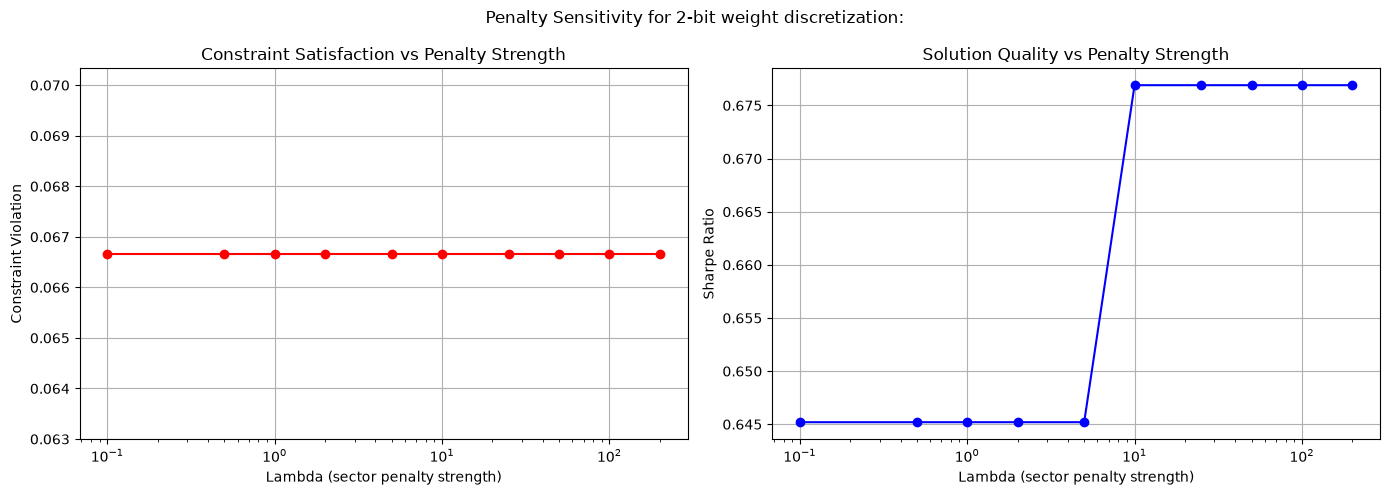

In [9]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Penalty Sensitivity for 2-bit weight discretization:')
ax1.plot(lambda_values,sector_violations,'r-o')
ax1.set_xscale('log')
ax1.set_xlabel('Lambda (sector penalty strength)')
ax1.set_ylabel('Constraint Violation')
ax1.set_title('Constraint Satisfaction vs Penalty Strength')
ax1.grid(True)

ax2.plot(lambda_values,sharpe_ratios,'b-o')
ax2.set_xscale('log')
ax2.set_xlabel('Lambda (sector penalty strength)')
ax2.set_ylabel('Sharpe Ratio')
ax2.set_title('Solution Quality vs Penalty Strength')
ax2.grid(True)
plt.tight_layout()
plt.savefig('penalty_sensitivity_2bit.png', dpi=150,bbox_inches='tight')
plt.show()

In [10]:
noise = qml.device("default.mixed",wires=n_qubits)

def apply_depolarizing_noise(p_error):
    for i in range(n_qubits):
        qml.DepolarizingChannel(p_error,wires=i)

@qml.qnode(noise)
def noisy_qaoa_circuit(params,p,p_error):
    gammas,betas = params[:p],params[p:]
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    for layer in range(p):
        cost_layer(gammas[layer],cost_hamiltonian)
        apply_depolarizing_noise(p_error)
        mixer_layer(betas[layer])
        apply_depolarizing_noise(p_error)
    return qml.expval(cost_hamiltonian)

noise_levels= [0.0,0.01,0.05,0.1]
noisy_energies=[]
print("Optimization energy p=1 with different noise levels:")
for p_err in noise_levels:
    e=noisy_qaoa_circuit(result_p1.x,1,p_err) + offset
    noisy_energies.append(e)
    print(f"noise={p_err:.2f} | energy: {e:.4f}")
print("\nOptimization energy p=2 with different noise levels:")
for p_err in noise_levels:
    z=noisy_qaoa_circuit(result_p2.x,2,p_err) + offset
    noisy_energies.append(z)
    print(f"noise={p_err:.2f} | energy: {z:.4f}")

Optimization energy p=1 with different noise levels:
noise=0.00 | energy: -2.6054
noise=0.01 | energy: -2.5852
noise=0.05 | energy: -2.5105
noise=0.10 | energy: -2.4289

Optimization energy p=2 with different noise levels:
noise=0.00 | energy: -5.2482
noise=0.01 | energy: -5.0462
noise=0.05 | energy: -4.3463
noise=0.10 | energy: -3.6772


In [11]:
print("Final Benchmarking Summary (N=6 instance)")
print("="*70)
print(f"\n{'Method':<25}{'Sharpe':>10}{'Constraint':>18}{'Time(s)':>10}")
print(f"{'Constrained Markowitz':<25}{mw_sharpe:>10.4f}{'Exact':>18}{mw_time:>10.4f}")

qubo_ret=np.dot(weights_sa,mean_returns)
qubo_vol=np.sqrt(weights_sa@cov_matrix@weights_sa)
qubo_sharpe= (qubo_ret -0.05)/qubo_vol
sector0_sa = sum(weights_sa[i] for i in range(n_assets) if sector_map[i]==0)
print(f"{'QUBO + SA':<25}{qubo_sharpe:>10.4f}{f'{sector0_sa:.2%}':>18}{time_sa:>10.4f}")

print(f"\nNoise sensitivity (QAOA p=2, best noiseless params):")
for p_err, z in zip(noise_levels,noisy_energies):
    print(f"p_error={p_err:.2f}: energy={z:.4f}")


Final Benchmarking Summary (N=6 instance)

Method                       Sharpe        Constraint   Time(s)
Constrained Markowitz        0.6585             Exact    0.0045
QUBO + SA                    0.6452            66.67%    9.2153

Noise sensitivity (QAOA p=2, best noiseless params):
p_error=0.00: energy=-2.6054
p_error=0.01: energy=-2.5852
p_error=0.05: energy=-2.5105
p_error=0.10: energy=-2.4289
